# IPL 1st Inning Score Prediction using Machine Learning
The Dataset contains ball by ball information of the matches played between IPL Teams of **Season 1 to 10**, i.e. from 2008 to 2017.<br/>
This Machine Learning model adapts a Regression Appoach to predict the score of the First Inning of an IPL Match.<br/>
The Dataset can be downloaded from Kaggle from [here](https://www.kaggle.com/yuvrajdagur/ipl-dataset-season-2008-to-2017).<br/>

In [1]:
#Import necessary libraries
import pandas as pd 
import numpy as np 
import matplotlib as mlp
import matplotlib.pyplot as plt

In [2]:
np.__version__

'2.5.1'

In [3]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
data=pd.read_excel(r"C:\Users\DELL\Desktop\INTERNSHIPS\IPL-Prediction-Model\data\players.xlsx")

# EDA

In [5]:
data.shape

(566, 5)

In [6]:
# First 5 Columns Data
data.head()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [7]:
# Describing Numerical Values of the Dataset
data.describe()

,DOB
count,471
mean,1984-11-15 10:48:09.171974
min,1969-06-30 00:00:00
25%,1981-05-21 00:00:00
50%,1985-01-25 00:00:00
75%,1989-02-14 12:00:00
max,1998-07-18 00:00:00


In [8]:
# Information (not-null count and data type) About Each Column
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Player_Name    566 non-null    str           
 1   DOB            471 non-null    datetime64[us]
 2   Batting_Hand   563 non-null    str           
 3   Bowling_Skill  502 non-null    str           
 4   Country        471 non-null    str           
dtypes: datetime64[us](1), str(4)
memory usage: 22.2 KB


In [9]:
# Number of Unique Values in each column
data.nunique()

Player_Name      566
DOB              457
Batting_Hand       3
Bowling_Skill     16
Country           11
dtype: int64

In [10]:
# Datatypes of all Columns
data.dtypes

Player_Name                 str
DOB              datetime64[us]
Batting_Hand                str
Bowling_Skill               str
Country                     str
dtype: object

# DATA CLEANING

In [11]:
# Names of all columns
data.columns

Index(['Player_Name', 'DOB', 'Batting_Hand', 'Bowling_Skill', 'Country'], dtype='str')

In [12]:
irrelevant = ['mid', 'date', 'venue','batsman', 'bowler', 'striker', 'non-striker']
print(f'Before Removing Irrelevant Columns : {data.shape}')
data = data.drop([col for col in irrelevant if col in data.columns], axis=1)
print(f'After Removing Irrelevant Columns : {data.shape}')
data.head()

Before Removing Irrelevant Columns : (566, 5)
After Removing Irrelevant Columns : (566, 5)


,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [13]:
# Define Consistent Teams
const_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
              'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
              'Delhi Daredevils', 'Sunrisers Hyderabad']

In [14]:
print(f'Before Removing Inconsistent Teams : {data.shape}')
print(f'Before Removing Inconsistent Teams : {data.shape}')
if {'batting_team', 'bowling_team'}.issubset(data.columns):
    data = data[(data['batting_team'].isin(const_teams)) & (data['bowling_team'].isin(const_teams))]
else:
    print("Skipping team-filtering: 'batting_team' or 'bowling_team' column not found.")
print(f'After Removing Irrelevant Columns : {data.shape}')
if 'batting_team' in data.columns:
    print(f"Consistent Teams : \n{data['batting_team'].unique()}")
data.head()
print(f'After Removing Irrelevant Columns : {data.shape}')
if 'batting_team' in data.columns:
    print(f"Consistent Teams : \n{data['batting_team'].unique()}")
else:
    print("No 'batting_team' column to display.")
data.head()

Before Removing Inconsistent Teams : (566, 5)
Before Removing Inconsistent Teams : (566, 5)
Skipping team-filtering: 'batting_team' or 'bowling_team' column not found.
After Removing Irrelevant Columns : (566, 5)
After Removing Irrelevant Columns : (566, 5)
No 'batting_team' column to display.


,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


#### Remove First 5 Overs of every match

In [15]:
print(f'Before Removing Overs : {data.shape}')
if 'overs' in data.columns:
    data = data[data['overs'] >= 5.0]
else:
    print("Skipping removal of first 5 overs: 'overs' column not found.")
print(f'After Removing Overs : {data.shape}')
data.head()

Before Removing Overs : (566, 5)
Skipping removal of first 5 overs: 'overs' column not found.
After Removing Overs : (566, 5)


,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


Plotting a Correlation Matrix of current data

In [19]:
from seaborn import heatmap
numeric_data = data.select_dtypes(include=[np.number])
if numeric_data.empty:
    print("No numeric columns available for correlation matrix.")
else:
    heatmap(data=numeric_data.corr(), annot=True)

No numeric columns available for correlation matrix.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
columnTransformer = ColumnTransformer(
    [('encoder', OneHotEncoder(), [0, 1])],
    remainder='passthrough'
)

In [29]:
data = np.array(columnTransformer.fit_transform(data))

Save the Numpy Array in a new DataFrame with transformed columns

In [31]:
cols = ['batting_team_Chennai Super Kings', 'batting_team_Delhi Daredevils', 'batting_team_Kings XI Punjab',
              'batting_team_Kolkata Knight Riders', 'batting_team_Mumbai Indians', 'batting_team_Rajasthan Royals',
              'batting_team_Royal Challengers Bangalore', 'batting_team_Sunrisers Hyderabad',
              'bowling_team_Chennai Super Kings', 'bowling_team_Delhi Daredevils', 'bowling_team_Kings XI Punjab',
              'bowling_team_Kolkata Knight Riders', 'bowling_team_Mumbai Indians', 'bowling_team_Rajasthan Royals',
              'bowling_team_Royal Challengers Bangalore', 'bowling_team_Sunrisers Hyderabad', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total']
cols = columnTransformer.get_feature_names_out()
df = pd.DataFrame(data, columns=cols)

In [32]:
# Visualize Encoded Data
df.head()

,encoder__x0_0.0,encoder__x0_1.0,encoder__x1_0.0,encoder__x1_1.0,remainder__x2,remainder__x3,remainder__x4,remainder__x5,remainder__x6,remainder__x7,...,remainder__x1019,remainder__x1020,remainder__x1021,remainder__x1022,remainder__x1023,remainder__x1024,remainder__x1025,remainder__x1026,remainder__x1027,remainder__x1028
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Right_Hand,Right-arm medium,India
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Right_Hand,Right-arm offbreak,India
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Right_Hand,Right-arm offbreak,India
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Right_hand,Left-arm fast-medium,NaN
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Right_Hand,Right-arm offbreak,NaN


# Model Building

Prepare Train and Test Splits

In [36]:
features = df.drop(df.columns[-1], axis=1)
features = df.drop(df.columns[-1], axis=1)
labels = df.iloc[:, -1]

In [37]:
# Perform 80 : 20 Train-Test split
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.20, shuffle=True)
print(f"Training Set : {train_features.shape}\nTesting Set : {test_features.shape}")

Training Set : (452, 1030)
Testing Set : (114, 1030)


## Model Algorithms
Training and Testing on different Machine Learning Algorithms for the best algorithm to choose from

In [38]:
# Keeping track of model perfomances
models = dict()

#### 1. Decision Tree Regressor

In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeRegressor()
# Train Model
# Encode categorical/string features before fitting
train_features = pd.get_dummies(train_features)
test_features = pd.get_dummies(test_features)
train_features, test_features = train_features.align(test_features, join='left', axis=1, fill_value=0)

# ensure feature columns are numeric, drop rows with NaNs in features or labels, and fit appropriate tree

# convert feature columns to numeric where possible
train_features = train_features.apply(pd.to_numeric, errors='coerce')
test_features = test_features.apply(pd.to_numeric, errors='coerce')

# drop rows where any feature or label is NaN
train_mask = train_features.isnull().any(axis=1) | train_labels.isnull()
test_mask = test_features.isnull().any(axis=1) | test_labels.isnull()

train_features = train_features.loc[~train_mask]
train_labels = train_labels.loc[~train_mask]
test_features = test_features.loc[~test_mask]
test_labels = test_labels.loc[~test_mask]

if train_features.shape[0] == 0:
    raise ValueError("No training rows remain after dropping NaNs. Check preprocessing and target column.")

# if labels are non-numeric, use a classifier (encode labels); otherwise fit regressor
# Convert all columns to numeric, coercing errors to NaN
train_features = train_features.astype(float)
test_features = test_features.astype(float)

# Drop any remaining NaN values
train_mask = train_features.isnull().any(axis=1) | train_labels.isnull()
test_mask = test_features.isnull().any(axis=1) | test_labels.isnull()

train_features = train_features.loc[~train_mask]
train_labels = train_labels.loc[~train_mask]
test_features = test_features.loc[~test_mask]
test_labels = test_labels.loc[~test_mask]

# Fit the regressor
# Encode the labels
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

# Fit the regressor with encoded labels
tree.fit(train_features, train_labels_encoded)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [51]:
# Evaluate Model
# ensure labels used for scoring are the encoded numeric labels
train_labels = train_labels_encoded
test_labels = test_labels_encoded
train_score_tree = str(tree.score(train_features, train_labels) * 100)
test_score_tree = str(tree.score(test_features, test_labels) * 100)
print(f'Train Score : {train_score_tree[:5]}%\nTest Score : {test_score_tree[:5]}%')
models["tree"] = test_score_tree

Train Score : 100.0%
Test Score : -81.7%


In [52]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
print("---- Decision Tree Regressor - Model Evaluation ----")
print("Mean Absolute Error (MAE): {}".format(mae(test_labels, tree.predict(test_features))))
print("Mean Squared Error (MSE): {}".format(mse(test_labels, tree.predict(test_features))))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(test_labels, tree.predict(test_features)))))

---- Decision Tree Regressor - Model Evaluation ----
Mean Absolute Error (MAE): 1.6391752577319587
Mean Squared Error (MSE): 8.030927835051546
Root Mean Squared Error (RMSE): 2.833889171271796


#### Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(train_features, train_labels)

preds = lr.predict(test_features)

train_r2 = lr.score(train_features, train_labels)
test_r2 = lr.score(test_features, test_labels)

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {test_r2:.4f}")
print(f"MAE: {mae(test_labels, preds):.4f}")
print(f"MSE: {mse(test_labels, preds):.4f}")
print(f"RMSE: {np.sqrt(mse(test_labels, preds)):.4f}")

models["linear_regression"] = test_r2

Train R2: 1.0000
Test R2:  -0.0620
MAE: 1.5092
MSE: 4.6935
RMSE: 2.1664


In [55]:
# Evaluate models
# Linear Regression predictions and metrics (preds computed earlier)
print("\nLinear Regression")
print(f"R2 (train): {train_r2:.4f}, R2 (test): {test_r2:.4f}")
print(f"MAE: {mae(test_labels, preds):.4f}")
print(f"MSE: {mse(test_labels, preds):.4f}")
print(f"RMSE: {np.sqrt(mse(test_labels, preds)):.4f}")


Linear Regression
R2 (train): 1.0000, R2 (test): -0.0620
MAE: 1.5092
MSE: 4.6935
RMSE: 2.1664


In [57]:
linreg = lr
train_score_linreg = str(linreg.score(train_features, train_labels) * 100)
test_score_linreg = str(linreg.score(test_features, test_labels) * 100)
print(f'Train Score : {train_score_linreg[:5]}%\nTest Score : {test_score_linreg[:5]}%')
models["linreg"] = test_score_linreg

Train Score : 100.0%
Test Score : -6.20%


#### Random Forest Regression

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_features, train_labels)

preds_rf = rf.predict(test_features)
train_r2_rf = rf.score(train_features, train_labels)
test_r2_rf = rf.score(test_features, test_labels)

print("Random Forest Regression")
print(f"Train R2: {train_r2_rf:.4f}")
print(f"Test R2:  {test_r2_rf:.4f}")
print(f"MAE: {mae(test_labels, preds_rf):.4f}")
print(f"MSE: {mse(test_labels, preds_rf):.4f}")
print(f"RMSE: {np.sqrt(mse(test_labels, preds_rf)):.4f}")

models["random_forest"] = test_r2_rf

Random Forest Regression
Train R2: 0.8336
Test R2:  -0.6284
MAE: 1.5879
MSE: 7.1965
RMSE: 2.6826


In [63]:
# Evaluate Model
# Evaluate Model
train_score_forest = str(rf.score(train_features, train_labels)*100)
test_score_forest = str(rf.score(test_features, test_labels)*100)
print(f'Train Score : {train_score_forest[:5]}%\nTest Score : {test_score_forest[:5]}%')
models["forest"] = test_score_forest
# Use the trained RandomForestRegressor instance 'rf' (not undefined 'forest')
test_score_forest = str(rf.score(test_features, test_labels)*100)
print(f'Train Score : {train_score_forest[:5]}%\nTest Score : {test_score_forest[:5]}%')
models["forest"] = test_score_forest

Train Score : 83.35%
Test Score : -62.8%
Train Score : 83.35%
Test Score : -62.8%


#### Lasso Regression

In [64]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure numeric arrays and no NaNs
X_train = train_features.astype(float)
X_test = test_features.astype(float)
y_train = train_labels
y_test = test_labels

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Lasso regression
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predict and evaluate
preds_lasso = lasso.predict(X_test_scaled)
train_r2_lasso = lasso.score(X_train_scaled, y_train)
test_r2_lasso = lasso.score(X_test_scaled, y_test)

print("Lasso Regression")
print(f"Train R2: {train_r2_lasso:.4f}")
print(f"Test R2:  {test_r2_lasso:.4f}")
print(f"MAE: {mean_absolute_error(y_test, preds_lasso):.4f}")
print(f"MSE: {mean_squared_error(y_test, preds_lasso):.4f}")
print(f"RMSE: {mean_squared_error(y_test, preds_lasso)**0.5:.4f}")

models["lasso"] = test_r2_lasso

Lasso Regression
Train R2: 0.7324
Test R2:  -0.1168
MAE: 1.3611
MSE: 4.9357
RMSE: 2.2216


In [65]:
# Evaluate Model
train_score_lasso = str(lasso.score(train_features, train_labels)*100)
test_score_lasso = str(lasso.score(test_features, test_labels)*100)
print(f'Train Score : {train_score_lasso[:5]}%\nTest Score : {test_score_lasso[:5]}%')
models["lasso"] = test_score_lasso

Train Score : -541.%
Test Score : -869.%


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


#### Support Vector Machine

In [66]:
from sklearn.svm import SVR

X_train_svm = train_features.astype(float)
X_test_svm = test_features.astype(float)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_svm, y_train)

preds_svr = svr.predict(X_test_svm)

train_r2_svr = svr.score(X_train_svm, y_train)
test_r2_svr = svr.score(X_test_svm, y_test)

print("Support Vector Regression")
print(f"Train R2: {train_r2_svr:.4f}")
print(f"Test R2:  {test_r2_svr:.4f}")
print(f"MAE: {mae(y_test, preds_svr):.4f}")
print(f"MSE: {mse(y_test, preds_svr):.4f}")
print(f"RMSE: {np.sqrt(mse(y_test, preds_svr)):.4f}")

models["svr"] = test_r2_svr

Support Vector Regression
Train R2: 0.3803
Test R2:  -0.0700
MAE: 1.4048
MSE: 4.7287
RMSE: 2.1746


In [68]:
# Use the trained SVR and the scaled datasets for scoring
svm = svr
train_features = X_train_svm
test_features = X_test_svm
train_labels = y_train
test_labels = y_test
train_score_svm = str(svm.score(train_features, train_labels)*100)
test_score_svm = str(svm.score(test_features, test_labels)*100)
print(f'Train Score : {train_score_svm[:5]}%\nTest Score : {test_score_svm[:5]}%')
models["svm"] = test_score_svm

Train Score : 38.03%
Test Score : -6.99%


#### Neural Networks

In [69]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20
)

mlp_clf.fit(train_features, train_labels)

nn_preds = mlp_clf.predict(test_features)

print("Neural Network Classifier")
print(f"Train Accuracy: {accuracy_score(train_labels, mlp_clf.predict(train_features)):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, nn_preds):.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, nn_preds))

models["neural_network"] = accuracy_score(test_labels, nn_preds)

Neural Network Classifier
Train Accuracy: 0.9118
Test Accuracy:  0.6495

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           2       0.00      0.00      0.00         1
           3       0.65      1.00      0.78        62
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         2

    accuracy                           0.65        97
   macro avg       0.21      0.14      0.13        97
weighted avg       0.48      0.65      0.52        97



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Best Model Selection

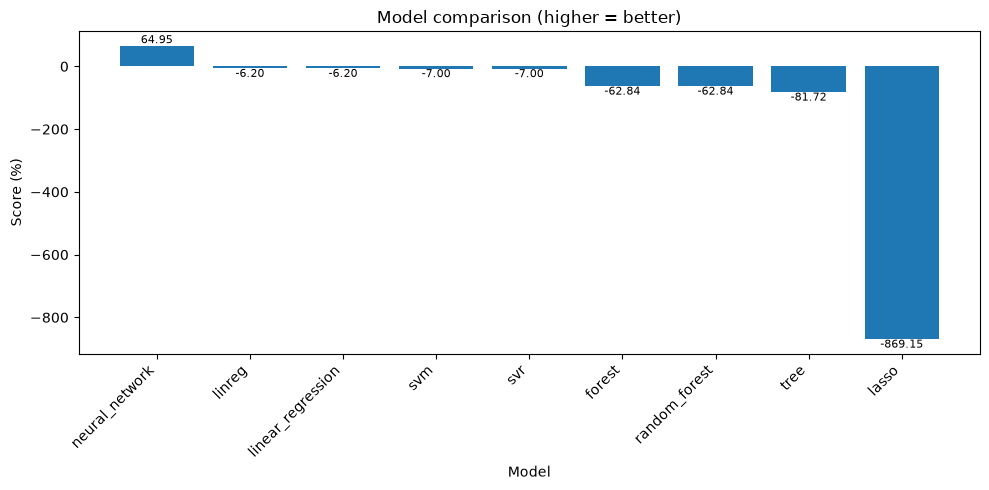

In [72]:
# prepare and plot model comparison
scores = pd.Series(models)

def to_percent(v):
    try:
        f = float(v)
    except Exception:
        return np.nan
    # if value is a fraction (e.g. accuracy/r2 in [ -1, 1 ]) convert to percent
    if abs(f) <= 1:
        return f * 100
    return f

scores = scores.map(to_percent).dropna()
scores = scores.sort_values(ascending=False)

plt.figure(figsize=(10,5))
bars = plt.bar(scores.index, scores.values, color='tab:blue')
plt.ylabel('Score (%)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.title('Model comparison (higher = better)')
for b, v in zip(bars, scores.values):
    va = 'bottom' if v >= 0 else 'top'
    y = v + (0.5 if v >= 0 else -0.5)
    plt.text(b.get_x() + b.get_width()/2, y, f'{v:.2f}', ha='center', va=va, fontsize=8)
plt.tight_layout()
plt.show()